# Bitcoin Next-Day Candle Direction — XGBoost with Technical + Macro Features

This is the consolidated, cleaned-up version of the project. It predicts the **direction**
of Bitcoin's next-day candle (`1` = up, `0` = down) using `XGBClassifier`, and adds two new
groups of features on top of the original ones:

1. **Technical indicators** computed from BTC's own price history (moving averages, RSI,
   MACD, volatility, momentum) — these are standard signals traders use to read price trend.
2. **Macro/cross-market features** — daily returns of the S&P 500 index and crude oil futures,
   since Bitcoin's price action is often correlated with broader risk sentiment and, at times,
   commodities.

All features are strictly backward-looking (computed only from data available up to and
including "today"), so there is no leakage of future information — this was the bug found and
removed in an earlier version borrowed from elsewhere; that version is not part of this
project anymore.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Download Data

Three tickers are pulled from `yfinance`:

- `BTC-USD` — the main asset we're predicting
- `^GSPC` — S&P 500 index, a broad proxy for equity market / risk sentiment
- `CL=F` — WTI crude oil futures

Stock and commodity markets are closed on weekends and holidays, while Bitcoin trades every
day. To align them, the macro series are reindexed onto BTC's calendar and forward-filled —
i.e., on a day the stock market is closed, we carry forward the last known return. That
reflects reality: no new information from that market arrived that day.


In [ ]:
START_DATE = "2015-01-01"

def download(ticker):
    d = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    return d.dropna()

btc = download("BTC-USD")
sp500 = download("^GSPC")
oil = download("CL=F")

btc.head(3)


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400


## 2. Feature Engineering

### Core price-action features (from the original version)
- `open_close = Open - Close`
- `low_high = Low - High`
- `pct_change`: 1-day return
- `volume_change`: 1-day % change in volume

### Technical indicators (new)
- `sma_7`, `sma_14`: 7- and 14-day simple moving averages of Close
- `ema_12`, `ema_26`: 12- and 26-day exponential moving averages
- `macd = ema_12 - ema_26`, `macd_signal`: standard MACD trend/momentum indicator
- `rsi_14`: 14-day Relative Strength Index — measures overbought/oversold conditions
- `volatility_7`: rolling 7-day standard deviation of daily returns
- `momentum_10`: `Close - Close.shift(10)` — how far price has moved over 10 days

Every one of these only uses data up to and including today — none of them peek at the future.


In [ ]:
df = btc.copy()

# Core features
df["open_close"] = df["Open"] - df["Close"]
df["low_high"] = df["Low"] - df["High"]
df["pct_change"] = df["Close"].pct_change()
df["volume_change"] = df["Volume"].pct_change()

# Moving averages
df["sma_7"] = df["Close"].rolling(window=7).mean()
df["sma_14"] = df["Close"].rolling(window=14).mean()
df["ema_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["ema_26"] = df["Close"].ewm(span=26, adjust=False).mean()

# MACD
df["macd"] = df["ema_12"] - df["ema_26"]
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

# RSI (14-day)
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))

# Volatility and momentum
df["volatility_7"] = df["pct_change"].rolling(window=7).std()
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

df.tail(3)


Price,Close,High,Low,Open,Volume,open_close,low_high,pct_change,volume_change,sma_7,sma_14,ema_12,ema_26,macd,macd_signal,rsi_14,volatility_7,momentum_10
Date,,,,,,,,,,,,,,,,,,
2026-09-11,77173.796875,79818.335938,76162.914062,76559.125000,37410998193,-614.671875,-3655.421875,0.007910,0.242060,78532.827009,78559.972656,78024.754446,76005.162213,2019.592232,2760.295950,47.614438,0.011182,-229.828125
2026-09-12,77270.468750,77479.656250,77045.000000,77175.070312,12664765797,-95.398438,-434.656250,0.001253,-0.661469,78168.055804,78490.305246,77908.710493,76098.888623,1809.821869,2570.201134,46.371717,0.011123,-30.007812
2026-09-13,76858.203125,77308.937500,76879.257812,77270.218750,12098297856,412.015625,-429.679688,-0.005335,-0.044728,77669.220982,78432.493304,77747.093974,76155.134142,1591.959832,2374.552874,46.951506,0.009981,-4413.539062


## 3. Macro / Cross-Market Features

Daily returns of the S&P 500 and crude oil, aligned onto BTC's calendar as described above.


In [ ]:
sp500_return = sp500["Close"].pct_change().rename("sp500_return")
oil_return = oil["Close"].pct_change().rename("oil_return")

df["sp500_return"] = sp500_return.reindex(df.index).ffill()
df["oil_return"] = oil_return.reindex(df.index).ffill()

df[["sp500_return", "oil_return"]].tail(3)


Price,sp500_return,oil_return
Date,,
2026-09-11,0.008599,-0.023712
2026-09-12,0.008599,-0.023712
2026-09-13,0.008599,-0.023712


## 4. Clean Up and Build the Target

Rolling-window features (like `sma_14`, `rsi_14`) create `NaN`s for the first ~26 rows until
enough history exists — those rows are dropped. The target is unchanged from before: `1` if
tomorrow's close is higher than today's close, else `0`.


In [ ]:
df = df.dropna()

FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "open_close", "low_high", "pct_change", "volume_change",
    "sma_7", "sma_14", "ema_12", "ema_26", "macd", "macd_signal",
    "rsi_14", "volatility_7", "momentum_10",
    "sp500_return", "oil_return",
]

X = df[FEATURE_COLS]
y = np.where(df["Close"].shift(-1) > df["Close"], 1, 0)

# drop the last row: no "tomorrow" to compare against yet
X = X.iloc[:-1]
y = y[:-1]

print("Feature count:", len(FEATURE_COLS))
print("Class balance (0=down, 1=up):")
print(pd.Series(y).value_counts(normalize=True))

X.shape, y.shape


Feature count: 20
Class balance (0=down, 1=up):
1    0.524771
0    0.475229
Name: proportion, dtype: float64


((4259, 20), (4259,))

## 5. Chronological Train/Test Split

Kept as before: `shuffle=False`, so the test set is strictly the most recent slice of time.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, shuffle=False, random_state=RANDOM_STATE
)

len(X_train), len(X_test)


(3833, 426)

## 6. Pipeline + GridSearchCV

- `TimeSeriesSplit(n_splits=5)` for cross-validation, so no future-into-past leakage during
  hyperparameter search.
- `scoring="f1_macro"`, so the search can't win by always predicting one class.
- If you're running this on a Colab GPU (T4), set `device="cuda"` below and keep `n_jobs=1` —
  running several folds in parallel on CPU while they all fight over one GPU tends to be
  slower, not faster.


In [ ]:
USE_GPU = True  # set to False to run on CPU

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
    ))
])

param_grid = {
    "xgb__n_estimators": [100, 200, 400],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=1 if USE_GPU else -1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV f1_macro:", grid_search.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [08:37:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Best CV f1_macro: 0.4762435716043337


## 7. Evaluation on the Test Set


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
preci = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print(f"accuracy:  {acc}")
print(f"f1:        {f1}")
print(f"precision: {preci}")
print(f"recall:    {recall}")
print()
print(classification_report(y_test, y_pred, zero_division=0))


accuracy:  0.4788732394366197
f1:        0.5394190871369294
precision: 0.4659498207885305
recall:    0.6403940886699507

              precision    recall  f1-score   support

           0       0.50      0.33      0.40       223
           1       0.47      0.64      0.54       203

    accuracy                           0.48       426
   macro avg       0.48      0.49      0.47       426
weighted avg       0.49      0.48      0.47       426



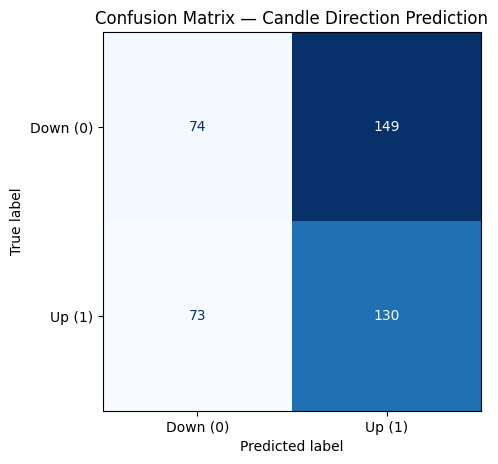

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Candle Direction Prediction")
plt.tight_layout()
plt.show()


## 8. Feature Importance

Worth checking whether the new technical/macro features actually get used by the model, or
whether the original simple features still dominate.


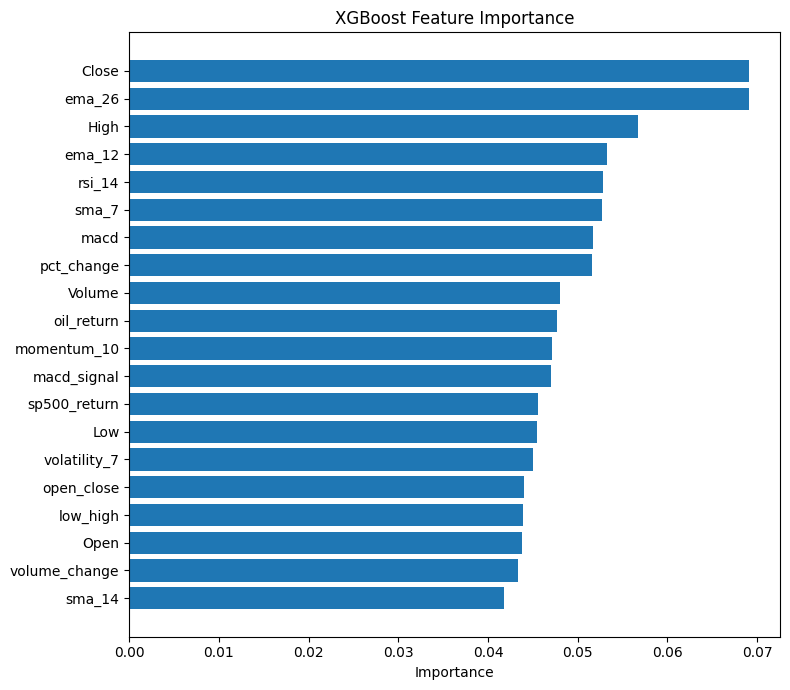

,feature,importance
3,Close,0.069112
12,ema_26,0.069086
1,High,0.056678
11,ema_12,0.053260
15,rsi_14,0.052853
9,sma_7,0.052677
13,macd,0.051725
7,pct_change,0.051652
4,Volume,0.048077
19,oil_return,0.047751


In [ ]:
importances = best_model.named_steps["xgb"].feature_importances_
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 7))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance_df


## 9. Predict Tomorrow's Candle Direction


In [ ]:
latest_features = X.iloc[[-1]]
tomorrow_class = best_model.predict(latest_features)[0]
tomorrow_proba_up = best_model.predict_proba(latest_features)[0, 1]

direction_label = "UP (bullish)" if tomorrow_class == 1 else "DOWN (bearish)"

print(f"Last known date: {X.index[-1].date()}")
print(f"Last known close: {df['Close'].iloc[-1]:.2f}")
print(f"Predicted next-day direction: {direction_label}")
print(f"Predicted probability of UP: {tomorrow_proba_up:.4f}")


Last known date: 2026-09-12
Last known close: 76858.20
Predicted next-day direction: UP (bullish)
Predicted probability of UP: 0.5032


## Notes

- All macro/technical features here are legitimate and leakage-free: each one only uses
  information that was actually available at the time. A borrowed notebook from elsewhere,
  which reached 96–99% accuracy through a feature that accidentally used tomorrow's price
  (`Close.shift(-1)` inside a feature instead of the target), has been removed from this
  project — it was not a real result.
- Realistic accuracy/F1 for this problem is still modest (often in the 50–58% range on
  held-out data). More features can help around the margins, but daily crypto direction is
  close to a random walk — treat any dramatically higher number as a sign to check for
  leakage first, not as a breakthrough.
- Next things worth trying: Bollinger Bands, on-chain metrics (if you have a data source),
  or predicting probability/confidence thresholds instead of a hard 0/1 call.
